Homework 3, part 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [3]:
np.random.seed(123)

n = 600
plan_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.35, 0.15])
tenure_days = np.random.randint(0, 366, n)
prior_sessions = np.random.poisson(12, n) + np.random.randint(0, 20, n)
platform = np.random.choice([0, 1], n, p=[0.6, 0.4])
signup_cohort = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])

logit_p = -2.0 + 0.5*plan_tier + 0.003*tenure_days + 0.02*prior_sessions + 0.4*platform + 0.2*signup_cohort
ps_true = 1 / (1 + np.exp(-np.clip(logit_p, -10, 10)))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

Y = 80 + 15*D + 8*plan_tier + 0.05*tenure_days + 0.8*prior_sessions + 5*platform + 3*signup_cohort + np.random.normal(0, 12, n)
Y = np.maximum(Y, 0)

df = pd.DataFrame({
    'plan_tier': plan_tier,
    'tenure_days': tenure_days,
    'prior_sessions': prior_sessions,
    'platform': platform,
    'signup_cohort': signup_cohort,
    'D': D,
    'weekly_active_minutes': Y
})

df.head()

,plan_tier,tenure_days,prior_sessions,platform,signup_cohort,D,weekly_active_minutes
0,1,231,16,1,2,0,132.725826
1,0,276,28,0,2,0,114.294894
2,0,345,21,0,1,1,136.288236
3,1,353,23,0,1,1,136.574351
4,1,39,15,0,0,0,113.114942


In [4]:
X = df[['plan_tier', 'tenure_days', 'prior_sessions', 'platform', 'signup_cohort']]
X_sm = sm.add_constant(X)

logit_model = sm.Logit(df['D'], X_sm).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.651636
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      D   No. Observations:                  600
Model:                          Logit   Df Residuals:                      594
Method:                           MLE   Df Model:                            5
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.04360
Time:                        11:19:44   Log-Likelihood:                -390.98
converged:                       True   LL-Null:                       -408.81
Covariance Type:            nonrobust   LLR p-value:                 1.115e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.2951      0.371     -3.490      0.000      -2.022      -0.568
plan_tier        

In [5]:
ps_model = LogisticRegression(max_iter=2000)
ps_model.fit(X, df['D'])

df['ps'] = ps_model.predict_proba(X)[:, 1]

# REQUIRED: clip to avoid extreme weights
df['ps'] = df['ps'].clip(0.01, 0.99)

df[['D', 'ps']].head()

,D,ps
0,0,0.619934
1,0,0.397479
2,1,0.393466
3,1,0.524070
4,0,0.321531


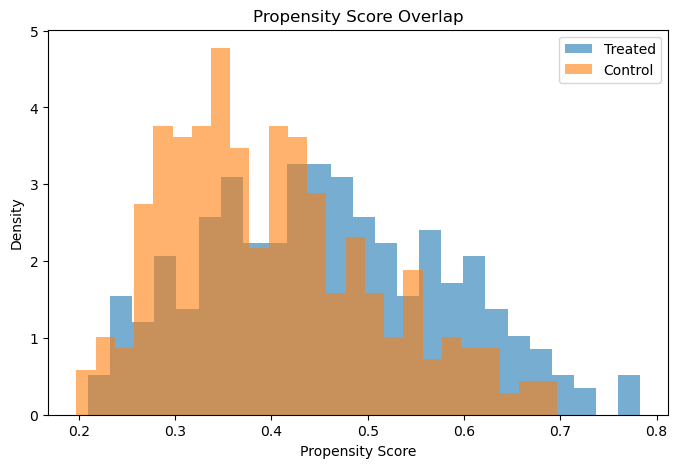

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df[df['D'] == 1]['ps'], bins=25, alpha=0.6, density=True, label='Treated')
plt.hist(df[df['D'] == 0]['ps'], bins=25, alpha=0.6, density=True, label='Control')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap')
plt.legend()
plt.show()

In [7]:
naive_ate = df[df['D'] == 1]['weekly_active_minutes'].mean() - df[df['D'] == 0]['weekly_active_minutes'].mean()
print(f"Naive ATE: {naive_ate:.3f}")

Naive ATE: 18.798


In [8]:
ipw_treated = (df['D'] * df['weekly_active_minutes'] / df['ps']).sum() / (df['D'] / df['ps']).sum()
ipw_control = (((1 - df['D']) * df['weekly_active_minutes']) / (1 - df['ps'])).sum() / (((1 - df['D']) / (1 - df['ps'])).sum())
ipw_ate = ipw_treated - ipw_control

print(f"IPW ATE: {ipw_ate:.3f}")
print("True effect: 15.000")

IPW ATE: 15.390
True effect: 15.000


The logistic regression shows that plan_tier, tenure_days, prior_sessions, platform, and signup_cohort increase the probability of receiving treatment.

The propensity score distributions for treated and control groups overlap sufficiently, so IPW is appropriate.

The naive ATE is larger than the true effect because treatment is not randomly assigned and more engaged users are more likely to receive treatment.

The IPW estimate is closer to the true effect of 15, showing that weighting corrects for selection on observables.